In [1]:
# Cell 1 - Import Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

print("All libraries imported successfully")


All libraries imported successfully


In [2]:
# Cell 2 - Define Dataset Paths
base_path = Path("../data/raw/Fundus_Train_Val_Data/Fundus_Scanes_Sorted")

train_neg = base_path / "Train/Glaucoma_Negative"
train_pos = base_path / "Train/Glaucoma_Positive"
val_neg = base_path / "Validation/Glaucoma_Negative"
val_pos = base_path / "Validation/Glaucoma_Positive"

print("Train - Normal    :", len(list(train_neg.glob("*"))))
print("Train - Glaucoma  :", len(list(train_pos.glob("*"))))
print("Val   - Normal    :", len(list(val_neg.glob("*"))))
print("Val   - Glaucoma  :", len(list(val_pos.glob("*"))))

Train - Normal    : 386
Train - Glaucoma  : 134
Val   - Normal    : 96
Val   - Glaucoma  : 34


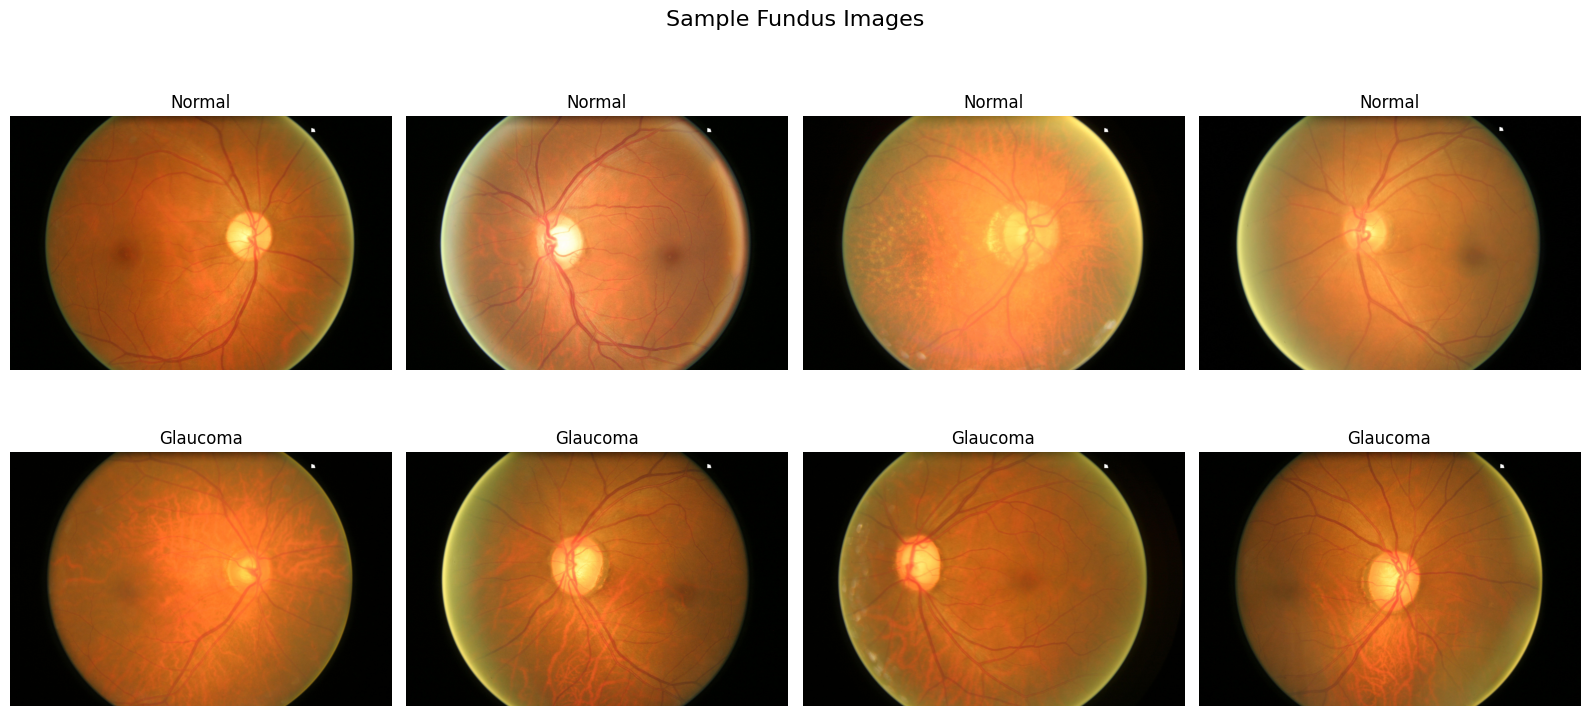

Sample images saved to results/plots/


In [3]:
import matplotlib.pyplot as plt
import cv2

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Sample Fundus Images", fontsize=16)

# Normal eyes
normal_images = list(train_neg.glob("*"))[:4]
for i, img_path in enumerate(normal_images):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img)
    axes[0, i].set_title("Normal")
    axes[0, i].axis("off")

# Glaucoma eyes
glaucoma_images = list(train_pos.glob("*"))[:4]
for i, img_path in enumerate(glaucoma_images):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img)
    axes[1, i].set_title("Glaucoma")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("../results/plots/sample_images.png")
plt.show()
print("Sample images saved to results/plots/")

In [4]:
# Check image dimensions across the dataset
sizes = []
for img_path in list(train_neg.glob("*")) + list(train_pos.glob("*")):
    img = cv2.imread(str(img_path))
    if img is not None:
        sizes.append(img.shape)

unique_sizes = set(sizes)
print(f"Total images checked: {len(sizes)}")
print(f"Unique sizes found: {len(unique_sizes)}")
for s in unique_sizes:
    print(s)

Total images checked: 520
Unique sizes found: 2
(2048, 3085, 3)
(2048, 3072, 3)


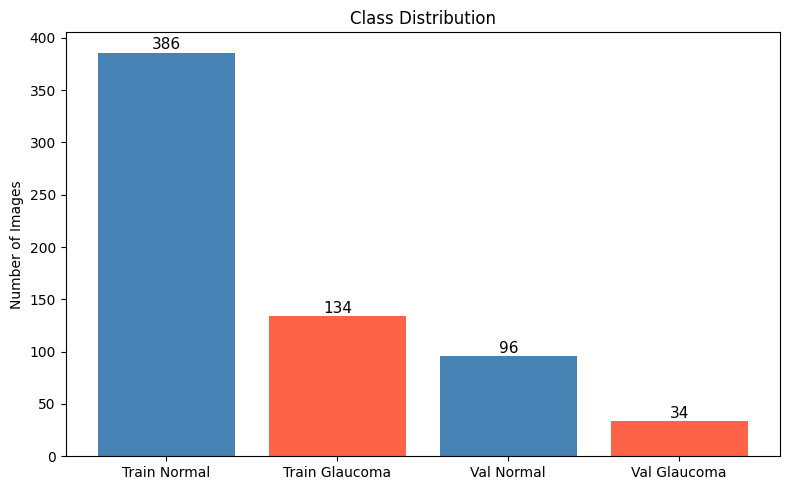

Class distribution saved


In [5]:
import matplotlib.pyplot as plt

# Class distribution
labels = ['Train Normal', 'Train Glaucoma', 'Val Normal', 'Val Glaucoma']
counts = [386, 134, 96, 34]
colors = ['steelblue', 'tomato', 'steelblue', 'tomato']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=colors)
plt.title("Class Distribution")
plt.ylabel("Number of Images")

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(count), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("../results/plots/class_distribution.png")
plt.show()
print("Class distribution saved")